In [1]:
!mkdir -p ~/work/human_segmentation/models
!mkdir -p ~/work/human_segmentation/images
!ls -s ~/data/* ~/work/human_segmentation/images

842 /home/jovyan/data/my_image.png

/home/jovyan/work/human_segmentation/images:
total 0


In [2]:
!pip install opencv-python pixellib


  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 56.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 119.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 52.2 MB/s eta 0:00:00:00:0100:01
  DEPRECATION: Building 'fvcore' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` 

In [5]:
import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print('슝=3')

슝=3


In [6]:
!wget https://d3s0tskafalll9.cloudfront.net/media/images/E-14-3.max-800x600_KwXP73b.png
!mv E-14-3.max-800x600_KwXP73b.png ~/work/human_segmentation/images/my_image.png

--2026-03-31 02:08:05--  https://d3s0tskafalll9.cloudfront.net/media/images/E-14-3.max-800x600_KwXP73b.png
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 54.230.71.23, 54.230.71.57, 54.230.71.78, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|54.230.71.23|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 662087 (647K) [image/png]
Saving to: ‘E-14-3.max-800x600_KwXP73b.png’

E-14-3.max-800x600_ 100%[===================>] 646.57K  --.-KB/s    in 0.06s   

2026-03-31 02:08:06 (10.1 MB/s) - ‘E-14-3.max-800x600_KwXP73b.png’ saved [662087/662087]



이미지 크기 : (450, 800, 3)


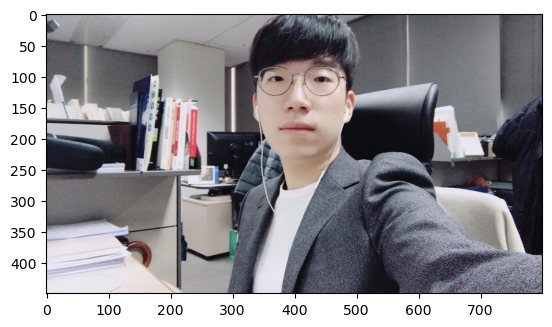

In [8]:
#준비한 이미지 파일의 경로를 이용하여, 이미지 파일을 읽음
#cv2.imread(경로) : 경로에 해당하는 이미지 파일을 읽어서 변수에 저장

home_dir = os.getenv('HOME')
img_path = os.path.join(home_dir, "work/human_segmentation/images/my_image.png")
img_orig = cv2.imread(img_path)

print(f"이미지 크기 : {img_orig.shape}")

# cv2. cvtColor(입력 이미지, 색상 변환 코드) : 입력 이미지의 색상 채널을 변경
# cv2. COLOR_BGR2RGB : 이미지 색상 채널을 변경 (BGR 형식을 RGB 형식으로 변경)
# plt.imshow() : 저장된 데이터를 이미지의 형식으로 표시, 입력은 RGB(A) 데이터 혹은 2D 스칼라 데이터
# https://matplot.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html
# plt.show() : 현재 열려있는 모든 figure를 표시 (여기서 figure는 이미지, 그래프 등)
# https://matplotlab.org/stab.e/api/_as_gen/matplotib.pyplot.show.html
plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
plt.show()




In [10]:
model = deeplabv3_resnet101(pretrained=True).eval()
# Torchvision에서 제공해주는 모델을 다운로드


/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /home/jovyan/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:02<00:00, 101MB/s]  


In [12]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)), # 모델 입력 크기 (고정)
    T.ToTensor(),
])
# 전처리 코드를 이용해 사용할 이미지를 전처리

In [14]:
input_tensor = transform(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)


In [17]:
%%time
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

    #원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (img_orig.shape[1], img_orig.shape[0]), interpolation=cv2.INTER_NEAREST)


CPU times: user 10.2 s, sys: 249 ms, total: 10.5 s
Wall time: 10.7 s


In [19]:
#pascalvoc 데이터의 라벨 종류
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]
len(LABEL_NAMES)


21

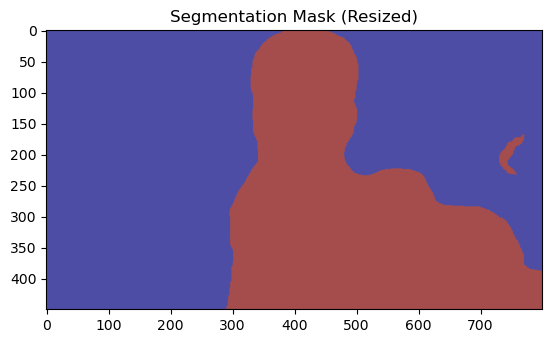

In [20]:
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()


In [21]:
unique_classes = np.unique(output_predictions_resized) #이미지 세그멘테이션 모델이 예측한 결과 배열 (np.unique() : 그 배열에서 중복을 제거하고 고유한 값만 추출하는 Numpy 함수)
unique_classes


array([ 0, 15], dtype=uint8)

In [23]:
for class_id in unique_classes : #unique_classes에서 클래스 ID를 하나씩 꺼냄
    print(LABEL_NAMES[class_id]) #ID를 인덱스로 사용해서 해당 클래스의 이름을 찾고 print로 출력 -> 클래스들을 고유번호들이 아닌 실제 이름으로 변환해서 보여주는 코
    

background
person


In [24]:
#아래 코드를 이해하지 않아도 좋습니다.
#PixelLib에서 그대로 가져온 코드입니다.
#주목해야 할 것은 생성 코드 결과물이예요

# 컬러맵 만들기
colormap = np.zeros((256, 3), dtype=int)
ind = np.arange(256, dtype=int)

for shift in reversed(range(8)):
    for channel in range(3):
        colormap[:, channel] |= ((ind >> channel) &1) << shift
    ind >>= 3

colormap[:20] # 생성한 20개의 컬러맵 출력

array([[  0,   0,   0],
       [128,   0,   0],
       [  0, 128,   0],
       [128, 128,   0],
       [  0,   0, 128],
       [128,   0, 128],
       [  0, 128, 128],
       [128, 128, 128],
       [ 64,   0,   0],
       [192,   0,   0],
       [ 64, 128,   0],
       [192, 128,   0],
       [ 64,   0, 128],
       [192,   0, 128],
       [ 64, 128, 128],
       [192, 128, 128],
       [  0,  64,   0],
       [128,  64,   0],
       [  0, 192,   0],
       [128, 192,   0]])

In [25]:
colormap[15] # 컬러맵 15에 해당하는 배열 출력 (pascalvoc에 LABEL_NAMES 15번째인 사람)


array([192, 128, 128])

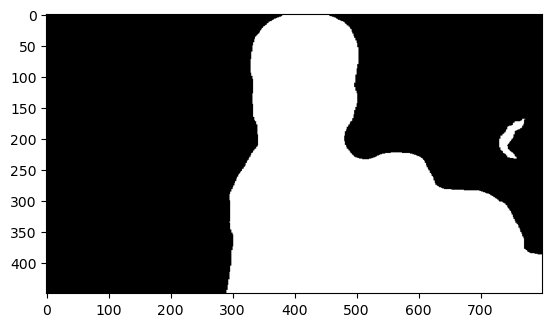

In [28]:
#output의 픽셀 별로 예측된 class가 사람이라면 1(True), 다르다면 0(False)이 됩니다.
#1과 0에 각각 255를 곱하였으므로 사람으로 예측된 픽셀은 255, 그렇지 않은 픽셀은 0
#cmap 값을 변경하면 다른 색상으로 확인이 가능함
seg_map = (output_predictions_resized == 15) # 클라스ID 15 (사람)
img_mask = seg_map.astype(np.uint8) * 255 # 255값으로 변환
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray')#흑백으로 표시
plt.show()


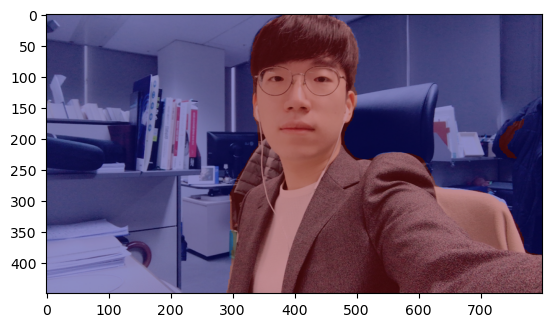

In [29]:
#원본 이미지와 마스트를 적당히 합쳐봅니다.
#0.6과 0.4는 두 이미지를 섞는 비율입니다

img_show = cv2. addWeighted(img_orig, 0.6, color_mask, 0.4, 0.0)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

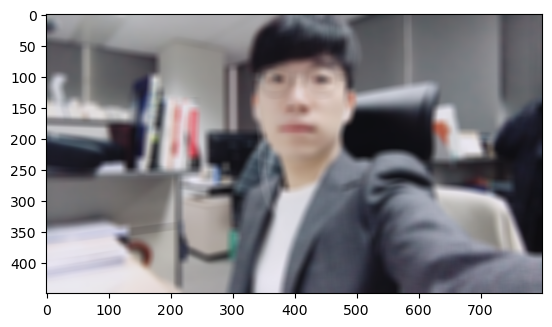

In [40]:
#(13, 13)은 blurring kernel size를 뜻합니다. 
#다양하게 바꿔보세요
img_orig_blur = cv2.blur(img_orig, (13, 13))

#plt.imshow() : 저장된 데이터를 이미지 형식으로 표시한다.
#cv2.cvtColor(입력이미지, 색상 변환 코드) : 입력 이미지의 색상 채널을 변경
#cv2.COLOR-BGR2RGB : 원본이 BGR 순서로 픽셀을 읽다보니
#이미지 색상 채널을 변경해야 함 (BGR형식을 RGB 형식으로 변경)
plt.imshow(cv2.cvtColor(img_orig_blur, cv2.COLOR_BGR2RGB))
plt.show()


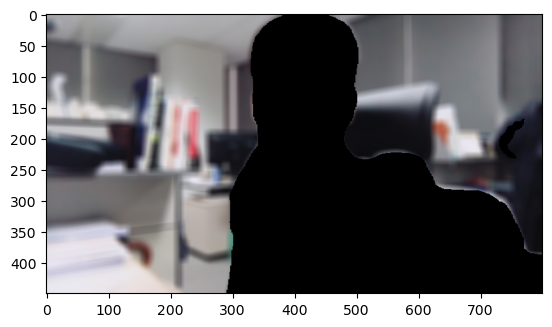

In [41]:
# 흐려진 이미지에서 세그멘테이션 마스크를 이용해서 배경만 추출

#cv2, cvtColor(입력 이미지, 색상 변환 코드) : 입력 이미지의 색상 채널을 변경
#cv2.COLOR_BGR2RGB : 원본이 BGR 순서로 픽셀을 읽다보니 이미지 색상 채널을 변경해야 함 (BGR 형식을 RGB 형식으로)
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

#cv2.bitwise_not() : 이미지가 반전됩니다. 배경이 0 사람이 255였으나 연산을 하고 나면 배경은 255 사람은 0입니다. 
img_bg_mask =cv2.bitwise_not(img_mask_color)

#cv2.bitwise_and()을 사용하면 배경만 있는 영상을 얻을 수 있습니다.
#0과 어떤 수를 bitwise_and 연산을 해도 0이 되기 때문에 사람이 0인 경우에는 사람이 있던 모든 픽셀이 0이 됩니다.
#결국 사람이 사라지고 배경만 남아요!
img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

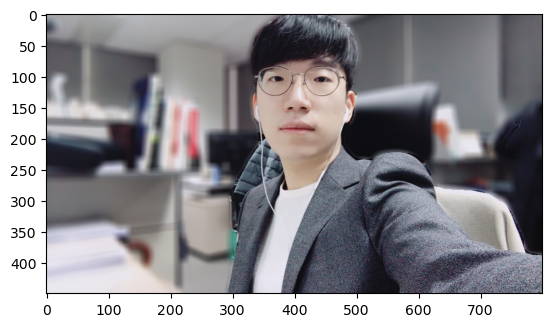

In [42]:
# 배경영상과 사람영상 합성

#np.where(조건, 참일때, 거짓일때) 
#세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가져오고
#아닌 영역은 블러된 이미지 값을 사용합니다. 

img_concat = np.where(img_mask_color==255, img_orig, img_bg_blur) 
#img_mask_color ==255 : 마스크가 흰색인 픽샐, 255인곳(사람/객체) -> img_orig 픽셀 사용, 255가 아닌곳(배경) ->img_bg_blur 픽셀 사용
# 결과 : img_concat = 객체는 선명하게 + 배경은 흐릿하게

#plt.imshow() : 저장된 데이터를 이미지 형식으로 표시한다
#cv2.cvtColor(입력 이미지, 색상 변환 코드) : 입력 이미지의 색상 채널 변경
#cv2.COLOR_BGR2RGB : 원본이 BGR 순서로 픽셀을 읽다보니 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

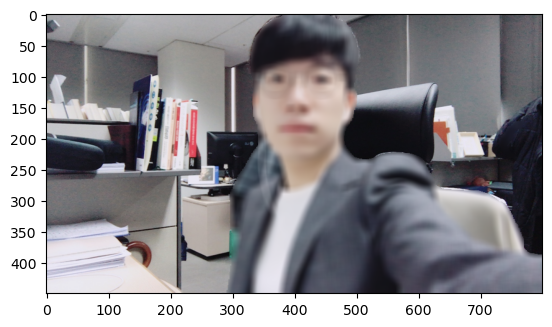

In [43]:
# Q. 이번에는 사람 부분을 블러로, 배경 부분을 원본으로 출력해볼까요?
# 힌트 : img_mask_color 옵션을 적절히 조정해주고, img_orig, img_orig_blur를 활용해보세요
img_concat = np.where(img_mask_color ==255, img_orig_blur, img_orig)
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

In [1]:
!pip install opencv-python pixellib

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Using cached lxml-6.0.2-cp312-cp312-manylinux_2_26_x86_64.manylinux_2_28_x86_64.whl.metadata (3.6 kB)
  Using cached xmljson-0.2.1-py2.py3-none-any.whl.metadata (12 kB)
  Using cached shapely-2.1.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.8 kB)
  Using cached sahi-0.11.36-py3-none-any.whl.metadata (19 kB)
  Using cached fire-0.7.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached opencv_python-4.11.0.86-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached pybboxes-0.1.6-py3-none-any.whl.metadata (9.9 kB)
  Using cached terminaltables-3.1.10-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached pyqt5_sip-12.18.0-cp312-cp312-manylinux_2_5_x86_64.manylinux1_x86_64.whl.metadata (495 bytes)
  Using cached pyqt5_qt5-5.15.18-py3-none-manylinux2014_x86_64.whl.metada

In [2]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print(cv2.__version__)

4.11.0


원본 고양이 이미지 크기 : (5256, 7900, 3)
배경(사막) 이미지 크기 : (3890, 5835, 3)


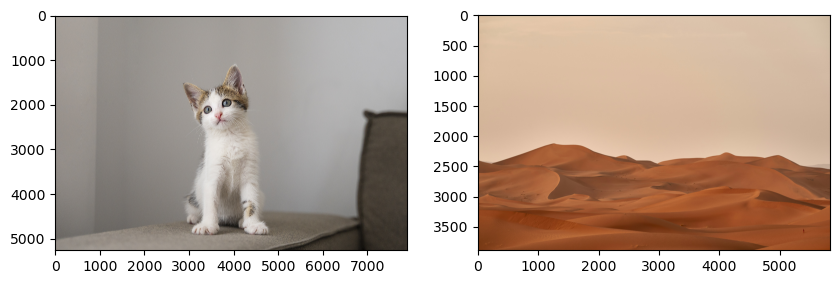

In [4]:
cat_img_path = "cat.jpg" # 고양이 이미지를 준비해주세요
sand_img_path = "sand.jpg" # 사막 배경 이미지를 준비해주세요

# 이미지 파일을 배열로 읽기
cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기 : {cat_img.shape}")
print(f"배경(사막) 이미지 크기 : {sand_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_img)

plt.subplot(1, 2, 2)
plt.imshow(sand_img)

plt.show()




In [6]:
# ResNet101을 백본으로 하는 DeepLabv3 세그멘테이션 모델
model = deeplabv3_resnet101(pretrained=True).eval() 
#COCO데이터셋으로 사전학습된 가중치를 자동 다운로드해서 로드
# 모델을 추론 모드로 전환 

#전처리 파이프라인 정의
transform = T.Compose([ #T.Compose는 여러 변환을 순서대로 연결하는 파이프라인
    T.ToPILImage(), # Numpy 배열(cv2로 읽은 이미지)을 PIL Image객체로 변환
    T.Resize((520, 520)), # 이미지를 520 X 520 픽셀로 리사이즈(Deeplabv3 권장입력크기)
    T.ToTensor(),#PIL Image를 pytorch텐서로 변환, 픽셀값을 0~255->0.0~1.0으로 정규화
])

#입력 텐서 생성
input_tensor = transform(cat_img).unsqueeze(0)
# 위 파이프라인 적용 -> (3, 520, 520) (채널, 높이, 너비)
#.unsqueeze(0) : 배치 차원 추가 -> (1, 3, 520, 520) 모델은 항상 배치 단위 입력을 기대함

# 추론
with torch.no_grad(): #역전파(gradient) 계산을 비활성화. 추론시 메모리 절약+속도향상
    output = model(input_tensor)["out"][0]
    #deeplabv3의 출력은 딕셔너리 형태 "out" 키가 메인 세그멘테이션 결과
    #-> shape:(1, 21, 520, 520) -> 배치 1장, 21개 클래스, 520x520
    #[0] : 배치차원 제거 -> shape : (21, 520, 520)
    output_predictions = output.argmax(0).byte().cpu().numpy()
    #output.argmax(0) : 21개 클래스 중 확률이 가장 높은 클래스 인덱스를 픽셀별로 선택-> shape : (520, 520), 
    #각 픽셀에 0~20 사이의 클래스 번호가 담김
print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")




추론 마스크 크기 (Before Resize): (520, 520)


In [8]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)
#Numpy와 OpenCV의 가로/세로 순서가 반대이기 때문에 [1](너비), [0](높이) 순으로 전달
print(f"추론 마스크 크기 (After Resize) : {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize) : (5256, 7900)


In [9]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID : {unique_classes}")

예측된 클래스 ID : [0 8]


### unique_classes에 담긴 클래스ID들을 하나씩 순회하면서 각 ID에 해당하는 클래스 이름을 출력 

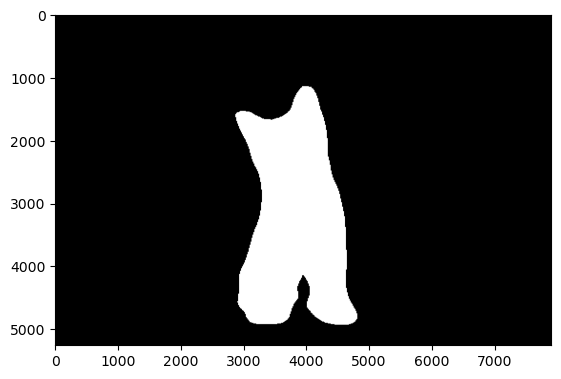

In [10]:
target_class_id = unique_classes[-1]
# unique_classes에서 마지막 클래스 ID를 선택, [-1]은 배열의 마지막 요소를 의미
# unique_classes = [0, 1, 3, 7]

seg_map = (output_predictions_resized == target_class_id)
# 예측결과 배열에서 target_class_id와 같은 픽셀만 True, 나머지는 False

img_mask = seg_map.astype(np.uint8) * 255
#Boolean(True/False) -> 숫자(1/0)로 변환 후 255를 곱함
#결과적으로 True->255(흰색), False->0(검정색)

plt.imshow(img_mask, cmap ='gray')
plt.show()

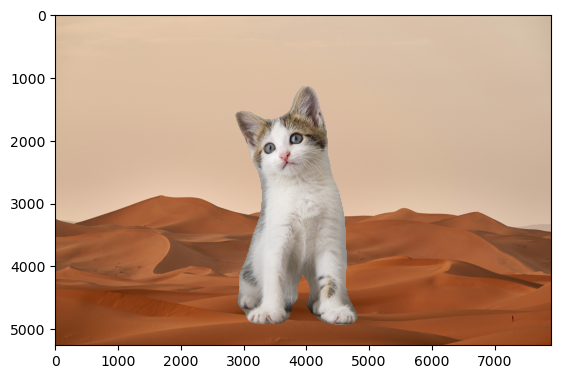

In [12]:
# 배경이미지 sand_img를 고양이 이미지 크기에 맞게 리사이즈
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))
# cat_img.shape[1] : 가로, cat_img.shape[0] : 세로
# 두 이미지 크기를 맞춰야 나중에 합성이 가능하기 때문

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR) 
# 흑백(1채널) 마스크 -> 컬러(3채널)로 변환
# 합성할 이미지가 BGR 3채널이기 때문에 채널수를 맞춰져야 함.

result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)#마스크 기반 합성

plt.imshow(result_img)
plt.show()

원본 셀피 이미지 크기 : (2630, 1482, 3)


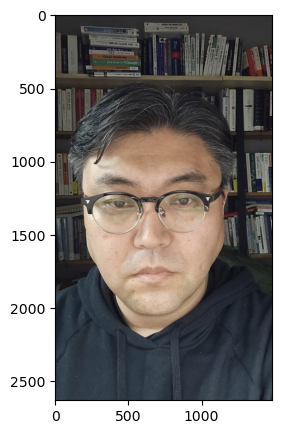

In [13]:
selfi_img_path = "selfi.jpg"

selfi_img = cv2.imread(selfi_img_path)

selfi_img = cv2.cvtColor(selfi_img, cv2.COLOR_BGR2RGB)

print(f"원본 셀피 이미지 크기 : {selfi_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(selfi_img)

plt.show()

In [14]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)), #모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(selfi_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")


추론 마스크 크기 (Before Resize): (520, 520)


In [15]:
# 마스크 크기를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (selfi_img.shape[1], selfi_img.shape[0]), interpolation=cv2.INTER_NEAREST)
print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (2630, 1482)


In [16]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [ 0 15]


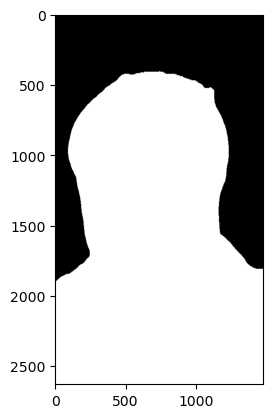

In [18]:
target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

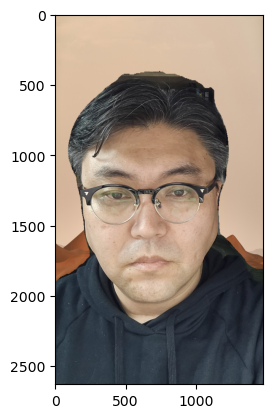

In [20]:
sand_img_resized = cv2.resize(sand_img, (selfi_img.shape[1], selfi_img.shape[0]))

img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)
result_img = np.where(img_mask_color == 255, selfi_img, sand_img_resized)

plt.imshow(result_img)
plt.show()

In [6]:
! pip install opencv-python pixellib # 다시 시작이 요구될 수 있습니다.

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 52.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 116.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 48.0 MB/s eta 0:00:0000:0100:01m
  DEPRECATION: Building 'fvcore' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` 

In [7]:
import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

In [8]:
!mv selfi.jpg ~/work/human_segmentation/images/my_image.jpg

이미지 크기: (2630, 1482, 3)


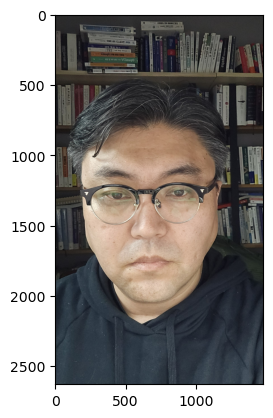

In [9]:
home_dir =os.getenv('HOME')
img_path =os.path.join(home_dir, "work/human_segmentation/images/my_image.jpg")
img_orig =cv2.imread(img_path)

print(f"이미지 크기: {img_orig.shape}")

plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
plt.show()

In [10]:
model = deeplabv3_resnet101(pretrained=True).eval()

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /home/jovyan/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:02<00:00, 83.8MB/s] 


In [11]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),
    T.ToTensor(),
])

In [12]:
input_tensor = transform(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)

In [13]:
%%time
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

output_predictions_resized = cv2.resize(output_predictions, (img_orig.shape[1], img_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

CPU times: user 9.36 s, sys: 110 ms, total: 9.47 s
Wall time: 9.6 s


In [14]:

LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]
len(LABEL_NAMES)

21

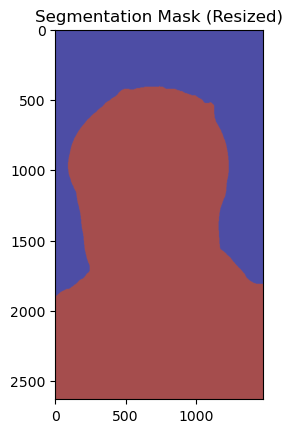

In [15]:
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()


In [16]:
unique_classes = np.unique(output_predictions_resized)
unique_classes

array([ 0, 15], dtype=uint8)

In [17]:
for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
person


In [18]:

colormap = np.zeros((256, 3), dtype=int)
ind = np.arange(256, dtype=int)

for shift in reversed(range(8)):
    for channel in range(3):
        colormap[:, channel] |= ((ind >> channel) & 1) << shift
    ind >>= 3

colormap[:20]  # 생성한 20개의 컬러맵 출력

array([[  0,   0,   0],
       [128,   0,   0],
       [  0, 128,   0],
       [128, 128,   0],
       [  0,   0, 128],
       [128,   0, 128],
       [  0, 128, 128],
       [128, 128, 128],
       [ 64,   0,   0],
       [192,   0,   0],
       [ 64, 128,   0],
       [192, 128,   0],
       [ 64,   0, 128],
       [192,   0, 128],
       [ 64, 128, 128],
       [192, 128, 128],
       [  0,  64,   0],
       [128,  64,   0],
       [  0, 192,   0],
       [128, 192,   0]])

In [19]:
colormap[15] 

array([192, 128, 128])

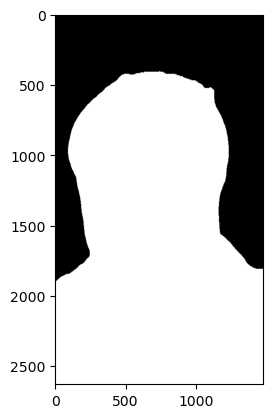

In [20]:
seg_map = (output_predictions_resized == 15)  # 클래스 ID 15 (사람)
img_mask = seg_map.astype(np.uint8) * 255  # 255 값으로 변환
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray')  # 흑백으로 표시
plt.show()

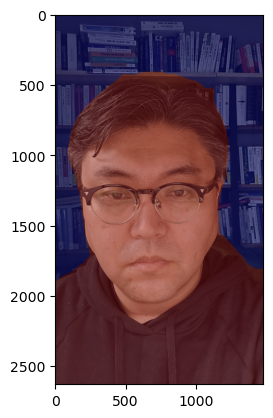

In [21]:
img_show = cv2.addWeighted(img_orig, 0.6, color_mask, 0.4, 0.0)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

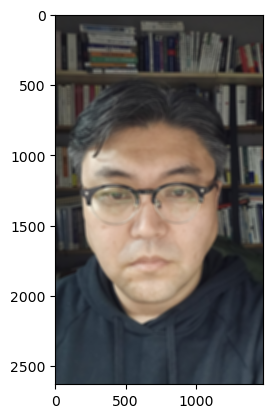

In [22]:
img_orig_blur = cv2.blur(img_orig, (24, 24))

plt.imshow(cv2.cvtColor(img_orig_blur, cv2.COLOR_BGR2RGB))
plt.show()

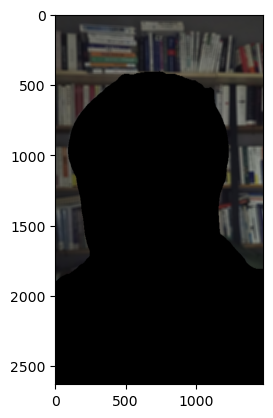

In [23]:
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

img_bg_mask = cv2.bitwise_not(img_mask_color)

img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

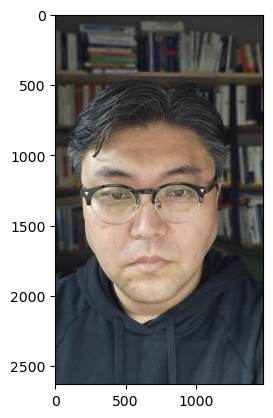

In [24]:
img_concat = np.where(img_mask_color==255, img_orig, img_bg_blur)
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

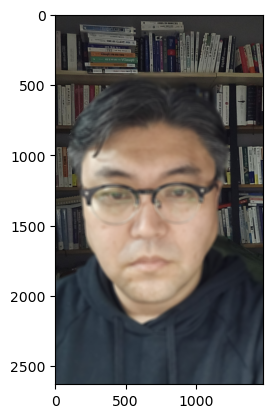

In [29]:
img_concat = np.where(img_mask_color == 255, img_orig_blur, img_orig)
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()